### Project: Titanic Machine Learning from Disaster

In [4]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [5]:
train_df = pd.read_csv('../data/train.csv')
test_df = pd.read_csv('../data/test.csv')

Notes:
* SipSp: of siblings/ spouses abroad the Titanic
* Parch: of parents/ children abroad the Titanic
* Ticket: Ticket number
* Cabin: Cabin number

In [6]:
train_df


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [7]:
# PassengerId not useful for prediction, so we can drop it from the training and test datasets.
train_df.set_index('PassengerId', inplace=True)

In [8]:
train_df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S


In [9]:
test_df.set_index('PassengerId', inplace=True)
test_df

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,
892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...
1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S



1. Feature Classification: Categorical vs Numerical
* help select the appropriate plots for visualization.

Which features are categorical?
* Categorical Features: nominal, ordinal, ratio, interval
* To classify the samples into sets of similar samples

Which features are numerical?
* Numerical features: discrete, contnuous, or timeseries 
* These values change from sample to sample

In [10]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


In [11]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 418 entries, 892 to 1309
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    418 non-null    int64  
 1   Name      418 non-null    object 
 2   Sex       418 non-null    object 
 3   Age       332 non-null    float64
 4   SibSp     418 non-null    int64  
 5   Parch     418 non-null    int64  
 6   Ticket    418 non-null    object 
 7   Fare      417 non-null    float64
 8   Cabin     91 non-null     object 
 9   Embarked  418 non-null    object 
dtypes: float64(2), int64(3), object(5)
memory usage: 35.9+ KB


- Categorical: Survival, Sex, embarked, Pclass(ordinal), SibSp, Parch
- Numerical: (continuous)Age, Fare
- Mix types of data: Ticket, Cabin
- Contain Error/Typo : Name
- Blank or Null: Cabin > Age > Embarked
- Various Data Type: String, Int, Float

In [27]:
# chuyen doi kieu du  lieu cac cot sau khi da xac dinh duoc cac cot nao la categorical va cot nao la numerical
train_df[["Survived", "Sex", "Pclass", "SibSp", "Parch", "Enbarked"]] = train_df[["Survived", "Sex", "Pclass", "SibSp", "Parch", "Embarked"]].astype("category")

In [29]:
test_df

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,
892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...
1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S


In [30]:
test_df[[ "Sex", "Pclass", "SibSp", "Parch","Embarked"]] = test_df[["Sex", "Pclass", "SibSp", "Parch","Embarked"]].astype("category")


#### EDA (Exploreatory Data Analysis)

In [14]:
train_df.info()
# phan loai cac cot theo kieu du lieu  
# cot age va cotcabin con nhieu null

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Survived  891 non-null    category
 1   Pclass    891 non-null    category
 2   Name      891 non-null    object  
 3   Sex       891 non-null    category
 4   Age       714 non-null    float64 
 5   SibSp     891 non-null    category
 6   Parch     891 non-null    category
 7   Ticket    891 non-null    object  
 8   Fare      891 non-null    float64 
 9   Cabin     204 non-null    object  
 10  Embarked  889 non-null    object  
dtypes: category(5), float64(2), object(4)
memory usage: 54.1+ KB


Distribution of Numerical feature values across the samples

In [15]:
train_df.describe()

,Age,Fare
count,714.000000,891.000000
mean,29.699118,32.204208
std,14.526497,49.693429
min,0.420000,0.000000
25%,20.125000,7.910400
50%,28.000000,14.454200
75%,38.000000,31.000000
max,80.000000,512.329200


##### Correlating categorical features
- Categorical: survival, sex, embarked, pclass, sibsp, parch

In [16]:
train_df.describe(include = "category")

,Survived,Pclass,Sex,SibSp,Parch
count,891,891,891,891,891
unique,2,3,2,7,7
top,0,3,male,0,0
freq,549,491,577,608,678


<Axes: xlabel='Survived'>

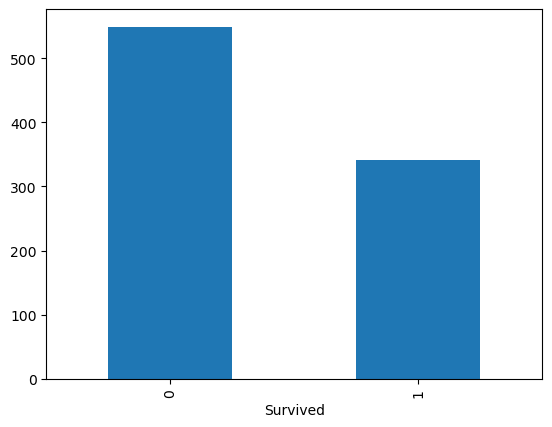

In [17]:
figure_survived = train_df['Survived'].value_counts()
figure_survived.plot(kind = "bar")

In [18]:
figure_survived = train_df['Survived'].value_counts(normalize = True)
figure_survived
## only 38% of the passengers survived, so the dataset is imbalanced. We will need to take this into account when we build our model.

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

In [19]:
train_df.Sex.value_counts(normalize = True)

Sex
male      0.647587
female    0.352413
Name: proportion, dtype: float64

In [20]:
related = train_df[['Survived', 'Sex']].groupby("Survived").value_counts()
related = related.to_frame()
related

C:\Users\admin\AppData\Local\Temp\ipykernel_26244\4159854769.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  related = train_df[['Survived', 'Sex']].groupby("Survived").value_counts()


count
Survived Sex          
0        male      468
         female     81
1        female    233
         male      109

In [21]:
related = train_df[['Survived', 'Sex']].groupby("Sex").value_counts(normalize = True)
related = related.to_frame()
related

C:\Users\admin\AppData\Local\Temp\ipykernel_26244\314194684.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  related = train_df[['Survived', 'Sex']].groupby("Sex").value_counts(normalize = True)


proportion
Sex    Survived            
female 1           0.742038
       0           0.257962
male   0           0.811092
       1           0.188908

<Axes: xlabel='Sex,Survived'>

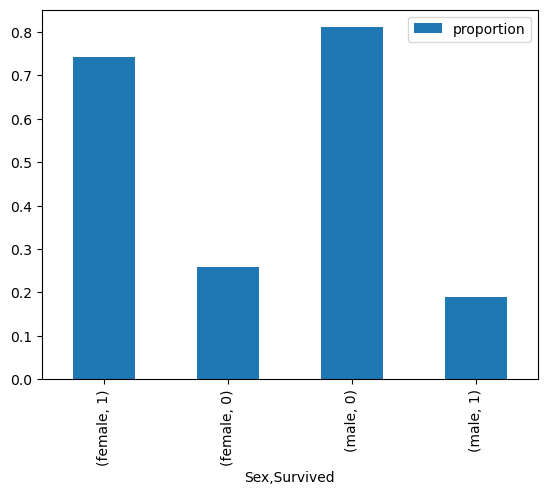

In [22]:
related.plot(kind = "bar")
# nam gioi co ti le song thap hon nu gioi du nhieu nguoi hon

<Axes: xlabel='Sex', ylabel='count'>

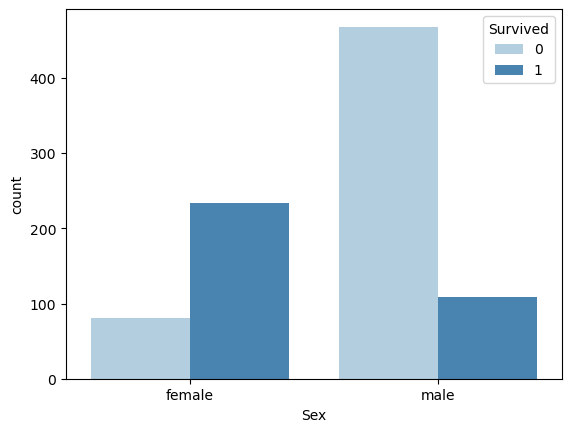

In [25]:
sns.countplot(data = train_df, x = 'Sex', hue = "Survived", palette= "Blues")

In [35]:
sup

,Sex,Pclass,SibSp,Parch,Embarked
PassengerId,,,,,
1,male,3,1,0,S
2,female,1,1,0,C
3,female,3,0,0,S
4,female,1,1,0,S
5,male,3,0,0,S
...,...,...,...,...,...
887,male,2,0,0,S
888,female,1,0,0,S
889,female,3,1,2,S


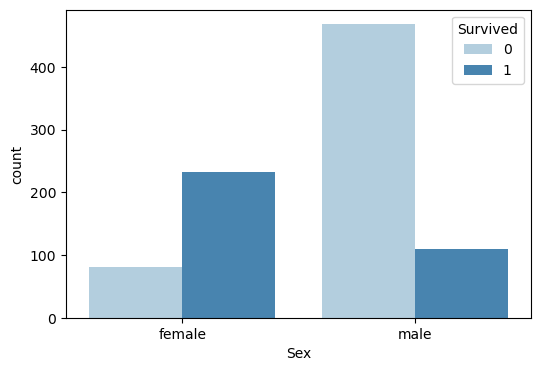

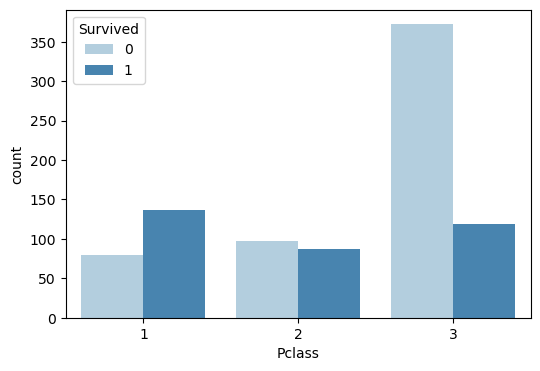

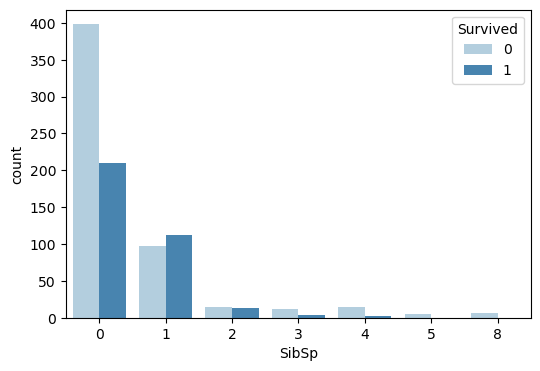

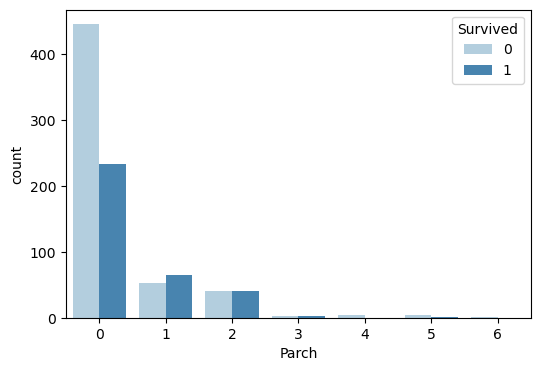

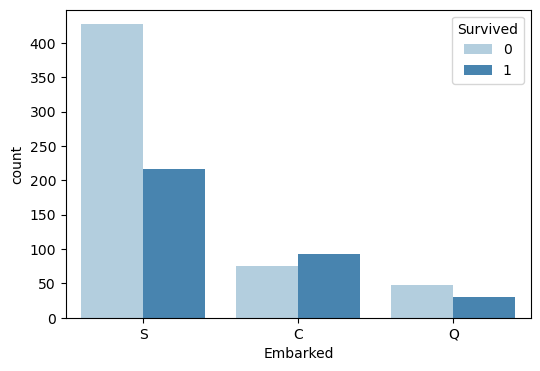

In [39]:
sup = train_df[["Sex", "Pclass", "SibSp", "Parch", "Embarked"]]
for i in sup :
    plt.figure(figsize = (6,4))
    sns.countplot(data = train_df, x = i, hue = "Survived", palette = "Blues")

Observation:
- Survival rate: 
    * male < female
    * Pclass 3 < 2 < 1 ( the higher class, the higher survival)
    * Genaraly take a trip with family or Sib has higher rating, family has 1-2 members has higher chances of survival
    * Embarked S < Q < C for survival rate


#### EDA for Numerical Features
 * Numerical features: Age, Fare

In [54]:
train_df[["Age", "Fare"]]

,Age,Fare
PassengerId,,
1,22.0,7.2500
2,38.0,71.2833
3,26.0,7.9250
4,35.0,53.1000
5,35.0,8.0500
...,...,...
887,27.0,13.0000
888,19.0,30.0000
889,NaN,23.4500


<Axes: xlabel='Age', ylabel='Count'>

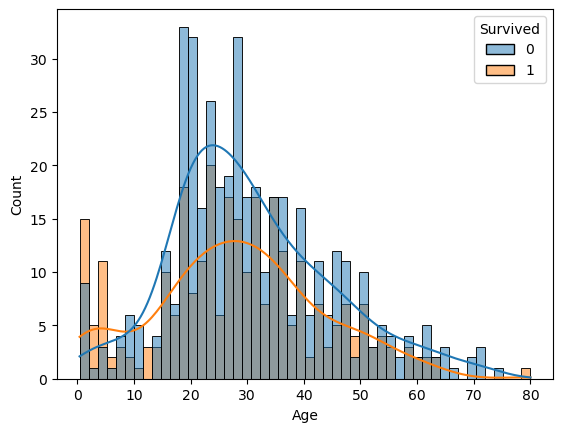

In [ ]:
sns.histplot(data = train_df, x = "Age",bins = 50, kde = True, hue = "Survived")
# Age impact to survival
# small people and old one are priotized

In [47]:
train_df["Fare"].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

<Axes: xlabel='Fare', ylabel='Count'>

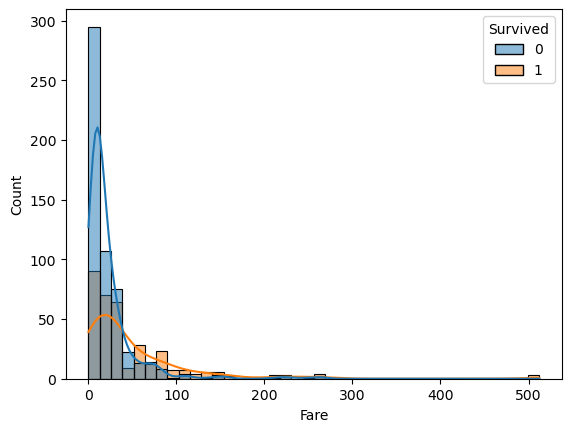

In [ ]:
sns.histplot(data = train_df, x = "Fare", bins = 40, kde = True, hue = "Survived")
# higher fee, money you spent on ticket that you are higher class, higher you survived

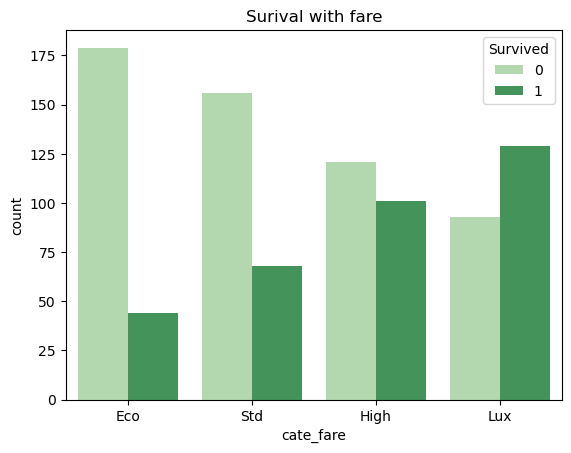

In [ ]:
fare_cate = ["Eco", "Std", "High", "Lux"]
train_df["cate_fare"] = pd.qcut(train_df["Fare"], 4, labels = fare_cate)
sns.countplot(data = train_df, x = "cate_fare", hue = "Survived", palette= "Greens");
plt.title("Surival with fare");


